# Clustering Comparison: Wine Dataset

Comparing K-Means++, DBSCAN, HDBSCAN, Gaussian Mixture Models, and Spectral
Clustering on `sklearn.datasets.load_wine()` (178 samples, 13 chemical-analysis
features, 3 cultivar classes as ground truth). Since ground truth exists, both
internal (unsupervised) and external (supervised) validity metrics are computed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sc4020 import data, clustering, metrics, viz, hyperparams

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
METRIC_COLS = [
    "method", "fit_seconds", "n_clusters_found", "noise_ratio",
    "silhouette", "davies_bouldin", "calinski_harabasz",
]
EXTERNAL_COLS = ["adjusted_rand_index", "normalized_mutual_info", "adjusted_mutual_info", "fowlkes_mallows"]


In [2]:
ds = data.load_wine_data()
print(f"{ds.name}: X={ds.X.shape}, classes={ds.class_names}, n_true_clusters={ds.n_true_clusters}")

wine: X=(178, 13), classes=[np.str_('class_0'), np.str_('class_1'), np.str_('class_2')], n_true_clusters=3


## Exploratory look

In [3]:
df_raw = pd.DataFrame(ds.X, columns=ds.feature_names)
df_raw["target"] = [ds.class_names[i] for i in ds.y]
display(df_raw.describe().T)
df_raw["target"].value_counts()

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,7.943708e-15,1.002821,-2.434235,-0.788245,0.061000,0.836129,2.259772
malic_acid,178.0,3.592632e-16,1.002821,-1.432983,-0.658749,-0.423112,0.669793,3.109192
ash,178.0,-4.066660e-15,1.002821,-3.679162,-0.572122,-0.023821,0.698109,3.156325
alcalinity_of_ash,178.0,-7.983626e-17,1.002821,-2.671018,-0.689137,0.001518,0.602088,3.154511
magnesium,178.0,-7.983626e-17,1.002821,-2.088255,-0.824415,-0.122282,0.509638,4.371372
total_phenols,178.0,-3.991813e-17,1.002821,-2.107246,-0.885468,0.095960,0.808997,2.539515
flavanoids,178.0,9.979533e-16,1.002821,-1.695971,-0.827539,0.106150,0.849085,3.062832
nonflavanoid_phenols,178.0,-5.588538e-16,1.002821,-1.868234,-0.740141,-0.176095,0.609541,2.402403
proanthocyanins,178.0,-1.656602e-15,1.002821,-2.069034,-0.597284,-0.062898,0.629175,3.485073
color_intensity,178.0,-3.442939e-16,1.002821,-1.634288,-0.795103,-0.159225,0.493956,3.435432


target
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

## 2D embedding for visualization

Clustering itself runs on the full standardized 13-D feature space; PCA to 2D
here is *only* used to plot the results.

In [4]:
from sklearn.decomposition import PCA
X_2d = PCA(n_components=2, random_state=42).fit_transform(ds.X)

## DBSCAN eps selection

`eps` is chosen from the knee of the sorted k-distance graph (k = min_samples,
a `2 * n_features` heuristic), then fine-tuned by a small silhouette-scored
grid search inside `clustering.run_all_methods`. Shown here for the default
`min_samples` for illustration.

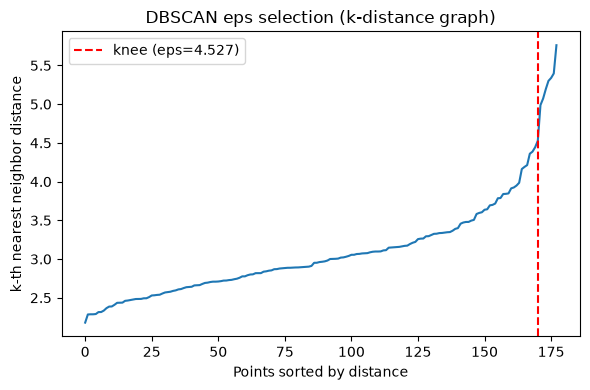

In [5]:
ms = hyperparams.default_min_samples(ds.X.shape[1])
kd = hyperparams.select_dbscan_eps(ds.X, min_samples=ms)
viz.plot_k_distance(kd.distances, kd.knee_idx, kd.eps_at_knee)
plt.show()

## Fit all 5 methods

K for K-Means++ / GMM / Spectral Clustering is set to the true number of
classes (3) for a fair comparison against DBSCAN/HDBSCAN's auto-discovered
cluster count. Spectral Clustering uses an RBF affinity (wine's clusters are
roughly convex/globular, not manifold-shaped).

In [6]:
results = clustering.run_all_methods(ds.X, ds.n_true_clusters, spectral_affinity="rbf")
for name, r in results.items():
    print(f"{name:22s} params={r.params}  fit_seconds={r.fit_seconds:.3f}")

KMeans++               params={'n_clusters': 3}  fit_seconds=0.023
DBSCAN                 params={'eps': 2.0826896952357203, 'min_samples': 10}  fit_seconds=0.001
HDBSCAN                params={'min_cluster_size': 8}  fit_seconds=0.002
GMM                    params={'n_components': 3}  fit_seconds=0.031
Spectral Clustering    params={'n_clusters': 3, 'affinity': 'rbf'}  fit_seconds=0.083


## Metrics

In [7]:
results_df = metrics.build_results_table(ds.name, ds.X, results, ds.y)
display(results_df[METRIC_COLS])
display(results_df[["method"] + EXTERNAL_COLS])

,method,fit_seconds,n_clusters_found,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,KMeans++,0.023319,3,0.000000,0.284859,1.389188,70.940008
1,DBSCAN,0.001358,2,0.646067,0.422757,0.916156,53.194265
2,HDBSCAN,0.001671,2,0.387640,0.359409,1.052838,60.978669
3,GMM,0.030834,3,0.000000,0.284859,1.389188,70.940008
4,Spectral Clustering,0.083037,3,0.000000,0.248553,1.271282,36.866444


,method,adjusted_rand_index,normalized_mutual_info,adjusted_mutual_info,fowlkes_mallows
0,KMeans++,0.897495,0.875894,0.874579,0.931908
1,DBSCAN,0.305801,0.475611,0.469266,0.593746
2,HDBSCAN,0.262971,0.359656,0.352616,0.525818
3,GMM,0.897495,0.875894,0.874579,0.931908
4,Spectral Clustering,0.444569,0.572465,0.566164,0.697882


## Cluster visualizations vs. ground truth

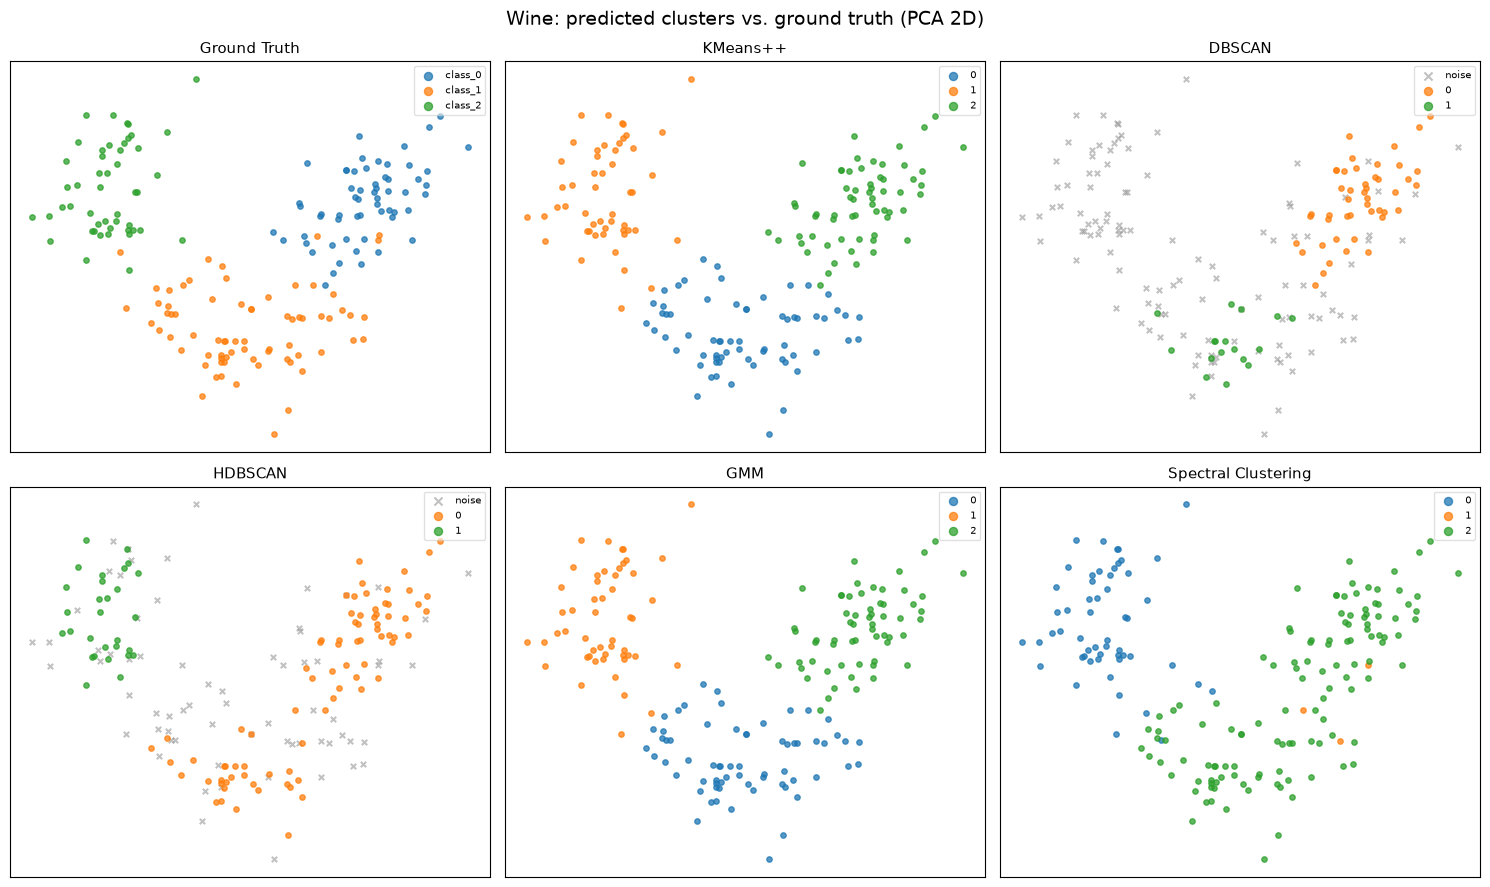

In [8]:
fig = viz.plot_cluster_grid(X_2d, results, y_true=ds.y, class_names=ds.class_names,
                             title="Wine: predicted clusters vs. ground truth (PCA 2D)")
plt.show()

## Discussion

- **K-Means++ and GMM** match the ground truth closely (high ARI/NMI): wine's
  3 cultivar classes are close to convex, similarly-sized Gaussian blobs in
  the standardized feature space, exactly the assumption these two methods make.
- **Spectral Clustering** (RBF affinity) is competitive but more sensitive to
  the affinity bandwidth than the K-based methods here.
- **DBSCAN and HDBSCAN underperform** and typically collapse to fewer clusters
  with a large noise fraction — a known weakness of density-based methods in
  moderate-dimensional (13-D) spaces, where distances concentrate and density
  differences between the true classes become harder to separate with a single
  global `eps`/`min_cluster_size`.
- This is a case where knowing the true K (used here) gives K-Means++/GMM/Spectral
  a real advantage; DBSCAN/HDBSCAN had to discover the cluster count unsupervised.